# Notebook Oficial del entrenamiento con MobileNetV3Large y TrashNet
Este notebook contiene los pasos para realizar el entrenamiento con MobileNetV3 y también vienen varias pruebas, el que mejor resultados ha dado es Transfer-Learning con Fine-Tuning (10 capas) con Loss 0.2636 y Accuracy Global de 91.82%

### Cargar librerías

In [2]:
import os
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from keras.layers import Conv2D, MaxPooling2D
from keras.initializers import RandomNormal, RandomUniform, GlorotUniform, HeNormal
from keras.models import load_model
from keras.layers import Dense, Dropout, BatchNormalization
import matplotlib.pyplot as plt

import onnxruntime as ort
import tf2onnx
from PIL import Image

### Paso 1: Crear la partición (Train, Validation y Test)

In [17]:
DATA_DIR = "/Users/jairpalma/Development/Reciclame/dataset-resized"
IMG_SIZE = (224, 224)
BATCH_SIZE = 64
SEED = 42

# 1. Obtener todas las rutas y sus etiquetas
class_names = []
folders = os.listdir(DATA_DIR)
for subfolder in folders:
    if os.path.isdir(os.path.join(DATA_DIR, subfolder)):
        class_names.append(subfolder)

class_to_idx = {cls_name: i for i, cls_name in enumerate(class_names)}

file_paths = []
labels = []

for cls_name in class_names:
    cls_folder = os.path.join(DATA_DIR, cls_name)
    if os.path.isdir(cls_folder):
        for fname in os.listdir(cls_folder):
            if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                file_paths.append(os.path.join(cls_folder, fname))
                labels.append(class_to_idx[cls_name])

# 2. Dividir: 70% Train, 15% Validation, 15% Test (Estratificado)
# Primer corte: 70% Train, 30% Temporal (Val + Test)
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    file_paths, labels, test_size=0.30, random_state=SEED, stratify=labels
)

# Segundo corte: Dividir el 30% a la mitad -> 15% Val y 15% Test
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.50, random_state=SEED, stratify=temp_labels
)

print(f"Total imágenes: {len(file_paths)}")
print(f"Entrenamiento : {len(train_paths)}")
print(f"Validación    : {len(val_paths)}")
print(f"Prueba (Test) : {len(test_paths)}")

Total imágenes: 2521
Entrenamiento : 1764
Validación    : 378
Prueba (Test) : 379


### Paso 2: Crear el pipeline de datos optimizado con tf.data

In [4]:
def load_and_preprocess_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    # MobileNetV3 espera entradas escaladas con su función respectiva
    img = keras.applications.mobilenet_v3.preprocess_input(img)
    return img, label

def create_dataset(paths, labels, is_training=False):
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    if is_training:
        dataset = dataset.shuffle(buffer_size=len(paths), seed=SEED)
    
    # Cargar imágenes en paralelo
    dataset = dataset.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE)
    # shuffle=False en validación y test es VITAL para no desalinear predicciones
    return dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

train_ds = create_dataset(train_paths, train_labels, is_training=True)
val_ds   = create_dataset(val_paths, val_labels, is_training=False)
test_ds  = create_dataset(test_paths, test_labels, is_training=False)

2026-09-15 16:35:13.536727: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-09-15 16:35:13.536772: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-09-15 16:35:13.536776: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
2026-09-15 16:35:13.536976: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-09-15 16:35:13.536991: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


### Paso 3: Data Augmentation

In [ ]:
# Definir el pipeline de Data Augmentation
# Enfoque a resaltar texturas y geometrias de las imágenes.
data_augmentation = keras.Sequential(
    [
        # keras.layers.RandomFlip("horizontal"),
        keras.layers.RandomRotation(0.2),       # Rotación aleatoria en rango [-10%, +10%]
        keras.layers.RandomZoom(0.2),           # Zoom aleatorio in/out
        keras.layers.RandomTranslation(0.05, 0.05), # Desplazamiento horizontal y vertical
        keras.layers.RandomContrast(0.2),       # Variación de contraste
    ],
    name="data_augmentation"
)

### Paso 4: Definir y Entrenar Modelos de MobileNetV3

#### Paso 4.1: Modelo 1 Large

In [ ]:
# Base preentrenada de MobileNetV3 Small
num_classes = len(class_names)

base_model = keras.applications.MobileNetV3Large(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)
base_model.trainable = False  # Congelado para fase inicial

# Ensamblar la arquitectura completa
inputs = keras.Input(shape=(224, 224, 3), name="input_image")

# Data augmentation se aplica primero (solo activo si training=True)
x = data_augmentation(inputs)

# MobileNetV3 con BatchNormalization congelada
x = base_model(x, training=False)

# Regularización y clasificación
x = keras.layers.Dropout(0.5)(x)

# Capa densa con regularización L2
x = Dense(512, activation='relu',
                    kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)

x = Dropout(0.3)(x)

# Capa densa con regularización L2
x = Dense(128, activation='relu',
                    kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)

x = Dropout(0.1)(x)

outputs = keras.layers.Dense(num_classes, activation='softmax', name="predictions")(x)

model = keras.Model(inputs, outputs)

# Compilación
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks útiles para evitar sobreajuste
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=2,
        min_lr=1e-6
    )
]

# Entrenamiento
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10


/opt/miniconda3/envs/tf_env/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


28/28 ━━━━━━━━━━━━━━━━━━━━ 18s 443ms/step - accuracy: 0.5402 - loss: 9.6579 - val_accuracy: 0.7831 - val_loss: 7.5074 - learning_rate: 0.0010
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 217ms/step - accuracy: 0.6667 - loss: 7.2546 - val_accuracy: 0.7963 - val_loss: 5.7096 - learning_rate: 0.0010
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 213ms/step - accuracy: 0.6888 - loss: 5.5994 - val_accuracy: 0.8042 - val_loss: 4.4827 - learning_rate: 0.0010
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 213ms/step - accuracy: 0.7080 - loss: 4.4002 - val_accuracy: 0.8122 - val_loss: 3.6576 - learning_rate: 0.0010
Epoch 5/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 212ms/step - accuracy: 0.7160 - loss: 3.5872 - val_accuracy: 0.8122 - val_loss: 2.9648 - learning_rate: 0.0010
Epoch 6/10
10/28 ━━━━━━━━━━━━━━━━━━━━ 3s 189ms/step - accuracy: 0.7375 - loss: 3.0344

#### Paso 4.2: Modelo 2 Pocas Epocas y solo una capa Dropout robusta al inicio

In [6]:
# Base preentrenada de MobileNetV3 Small
num_classes = len(class_names)

base_model = keras.applications.MobileNetV3Large(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)
base_model.trainable = False  # Congelado para fase inicial

# Ensamblar la arquitectura completa
inputs = keras.Input(shape=(224, 224, 3), name="input_image")

# Data augmentation se aplica primero (solo activo si training=True)
x = data_augmentation(inputs)

# MobileNetV3 con BatchNormalization congelada
x = base_model(x, training=False)

# Regularización y clasificación
x = keras.layers.Dropout(0.5)(x)

outputs = keras.layers.Dense(num_classes, activation='softmax', name="predictions")(x)

model = keras.Model(inputs, outputs)

# Compilación
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks útiles para evitar sobreajuste
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=2,
        min_lr=1e-6
    )
]

# Entrenamiento
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30


/opt/miniconda3/envs/tf_env/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
2026-09-15 16:36:02.590616: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


28/28 ━━━━━━━━━━━━━━━━━━━━ 14s 361ms/step - accuracy: 0.3532 - loss: 1.9561 - val_accuracy: 0.6508 - val_loss: 1.0189 - learning_rate: 0.0010
Epoch 2/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 201ms/step - accuracy: 0.5743 - loss: 1.1579 - val_accuracy: 0.7249 - val_loss: 0.7639 - learning_rate: 0.0010
Epoch 3/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 203ms/step - accuracy: 0.6644 - loss: 0.9436 - val_accuracy: 0.7778 - val_loss: 0.6566 - learning_rate: 0.0010
Epoch 4/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 204ms/step - accuracy: 0.7120 - loss: 0.7921 - val_accuracy: 0.7937 - val_loss: 0.6201 - learning_rate: 0.0010
Epoch 5/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 204ms/step - accuracy: 0.7523 - loss: 0.7209 - val_accuracy: 0.8228 - val_loss: 0.5837 - learning_rate: 0.0010
Epoch 6/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 207ms/step - accuracy: 0.7500 - loss: 0.6897 - val_accuracy: 0.8280 - val_loss: 0.5433 - learning_rate: 0.0010
Epoch 7/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 204ms/step - accuracy: 0.7738 - loss: 0.6415 - val_accura

#### Paso 4.4 Modelo Lerning Transfer + Fine Tuning

In [ ]:
# Base preentrenada de MobileNetV3 Small
num_classes = len(class_names)

base_model = keras.applications.MobileNetV3Large(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)
base_model.trainable = False  # Congelado para fase inicial

# Ensamblar la arquitectura completa
inputs = keras.Input(shape=(224, 224, 3), name="input_image")

# Data augmentation se aplica primero (solo activo si training=True)
x = data_augmentation(inputs)

# MobileNetV3 con BatchNormalization congelada
x = base_model(x, training=False)

# Regularización y clasificación
x = keras.layers.Dropout(0.5)(x)

outputs = keras.layers.Dense(num_classes, activation='softmax', name="predictions")(x)

model = keras.Model(inputs, outputs)

# Compilación
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

# Callbacks útiles para evitar sobreajuste
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=2,
        min_lr=1e-6
    )
]

# Entrenamiento - Learning Transfer
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks,
    batch_size=64
)

# Fine Tuning
base_model.trainable = True
# Congelar las primeras capas para conservar descriptores básicos de bajo nivel
for layer in base_model.layers[:-10]:
    layer.trainable = False

# Recompilar con tasa de aprendizaje significativamente menor
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine_tuning = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks,
    batch_size=128
)



Epoch 1/10


/opt/miniconda3/envs/tf_env/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


28/28 ━━━━━━━━━━━━━━━━━━━━ 16s 386ms/step - accuracy: 0.3481 - loss: 1.9537 - val_accuracy: 0.6270 - val_loss: 1.0327 - learning_rate: 0.0010
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 207ms/step - accuracy: 0.5539 - loss: 1.1891 - val_accuracy: 0.7275 - val_loss: 0.7891 - learning_rate: 0.0010
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 212ms/step - accuracy: 0.6525 - loss: 0.9512 - val_accuracy: 0.7540 - val_loss: 0.6822 - learning_rate: 0.0010
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 203ms/step - accuracy: 0.7132 - loss: 0.8073 - val_accuracy: 0.7963 - val_loss: 0.6041 - learning_rate: 0.0010
Epoch 5/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 204ms/step - accuracy: 0.7426 - loss: 0.7267 - val_accuracy: 0.7937 - val_loss: 0.5750 - learning_rate: 0.0010
Epoch 6/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 201ms/step - accuracy: 0.7591 - loss: 0.6473 - val_accuracy: 0.8175 - val_loss: 0.5367 - learning_rate: 0.0010
Epoch 7/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 197ms/step - accuracy: 0.7676 - loss: 0.6372 - val_accura

#### Paso 4.2: Modelo 3 Small

In [ ]:
num_classes = len(class_names)

# Cargar MobileNetV3 Small
base_model = keras.applications.MobileNetV3Small(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)

base_model.trainable = False  # Congelar base para transfer learning inicial

inputs = keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = keras.layers.Dropout(0.5)(x)
outputs = keras.layers.Dense(num_classes, activation='softmax')(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Entrenar evaluando en Validation
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

### Paso 5: Evaluar Métricas en Test (Precision, Recall, F1-Score)

#### Paso 5.1: Loss y Accuracy

In [7]:
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 277ms/step - accuracy: 0.8865 - loss: 0.3129
Test Loss:     0.3129
Test Accuracy: 88.65%


#### Paso 5.2: Precision, Recall y F1-Score por clase y globales

In [8]:
# Obtener predicciones en el conjunto de test
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# Las etiquetas reales corresponden exactamente a test_labels
# (dado que test_ds no fue mezclado/shuffled)
y_true = np.array(test_labels)

# Reporte completo con Precision, Recall y F1-Score por clase y globales
report = classification_report(
    y_true, 
    y_pred, 
    target_names=class_names,
    digits=4
)
print("=== REPORTE DE CLASIFICACIÓN (TEST SET) ===")
print(report)

6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 527ms/step
=== REPORTE DE CLASIFICACIÓN (TEST SET) ===
              precision    recall  f1-score   support

       paper     0.9213    0.9213    0.9213        89
       metal     0.8429    0.9516    0.8939        62
   cardboard     0.9180    0.9180    0.9180        61
       trash     0.7000    0.7000    0.7000        20
       glass     0.9028    0.8667    0.8844        75
     plastic     0.8955    0.8333    0.8633        72

    accuracy                         0.8865       379
   macro avg     0.8634    0.8652    0.8635       379
weighted avg     0.8877    0.8865    0.8863       379



#### Matriz de confusión

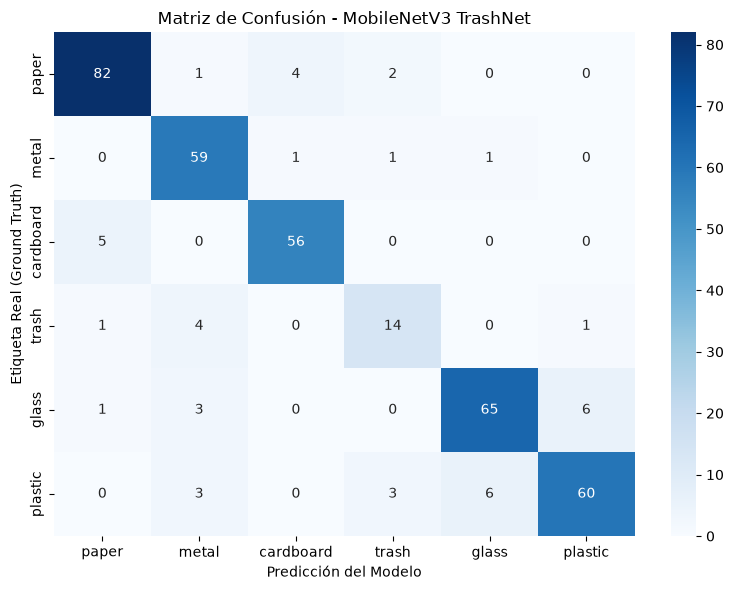

In [9]:
cm = confusion_matrix(y_true, y_pred)
# print(cm)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 3. Calcular la matriz
cm = confusion_matrix(y_true, y_pred)

# 4. Configurar y mostrar la gráfica
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)

plt.title('Matriz de Confusión - MobileNetV3 TrashNet')
plt.ylabel('Etiqueta Real (Ground Truth)')
plt.xlabel('Predicción del Modelo')
plt.tight_layout()
plt.show()

#### Paso 5.3: Gráficas de entrenamiento y pérdida

In [10]:
def plot_history(history_base, title_accuracy = 'Transfer Learning Accuracy', title_loss = 'Transfer Learning Loss'):
    """Visualizar historial de entrenamiento"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    # Accuracy Transfer Learning
    ax1.plot(history_base.history['accuracy'], label='Train')
    ax1.plot(history_base.history['val_accuracy'], label='Val')
    ax1.set_title(title_accuracy)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)

    # Loss Transfer Learning
    ax2.plot(history_base.history['loss'], label='Train')
    ax2.plot(history_base.history['val_loss'], label='Val')
    ax2.set_title(title_loss)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

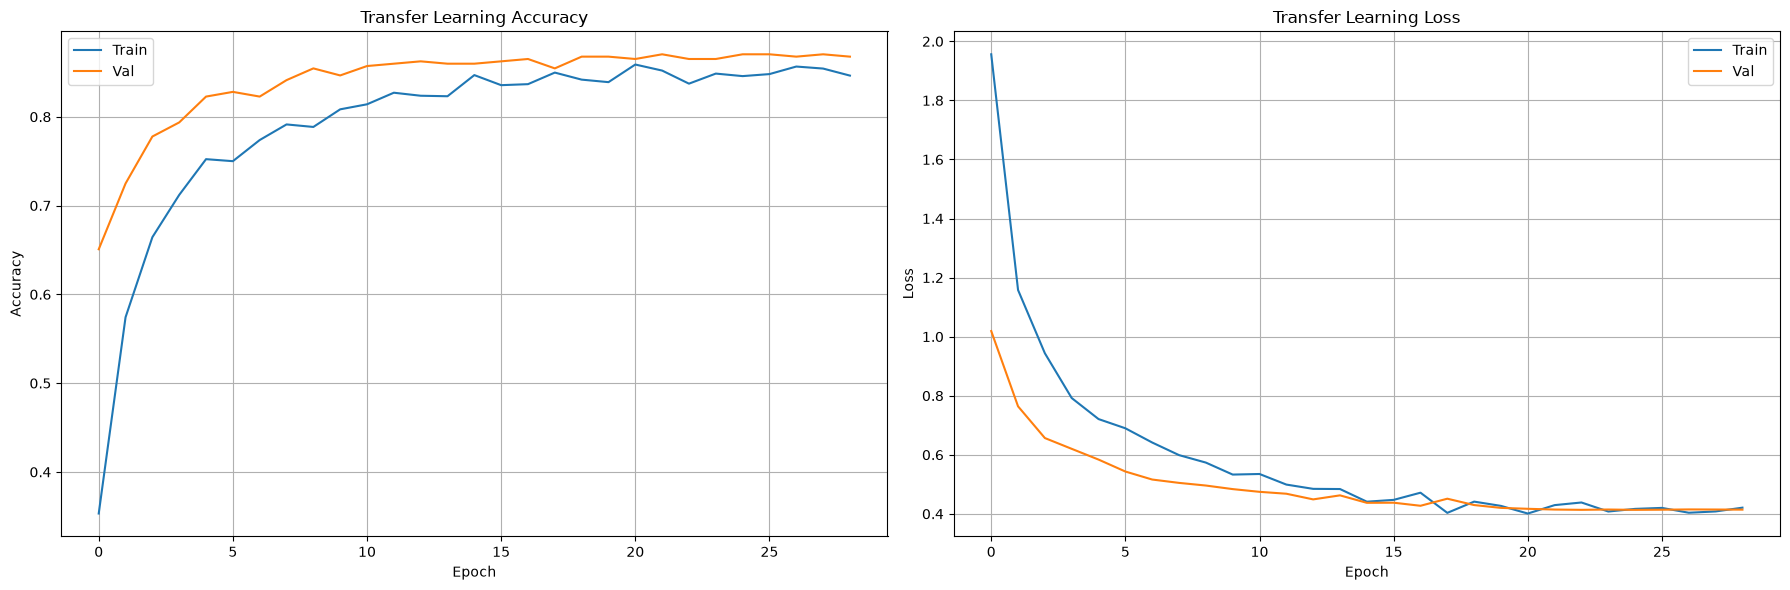

In [11]:
plot_history(history)

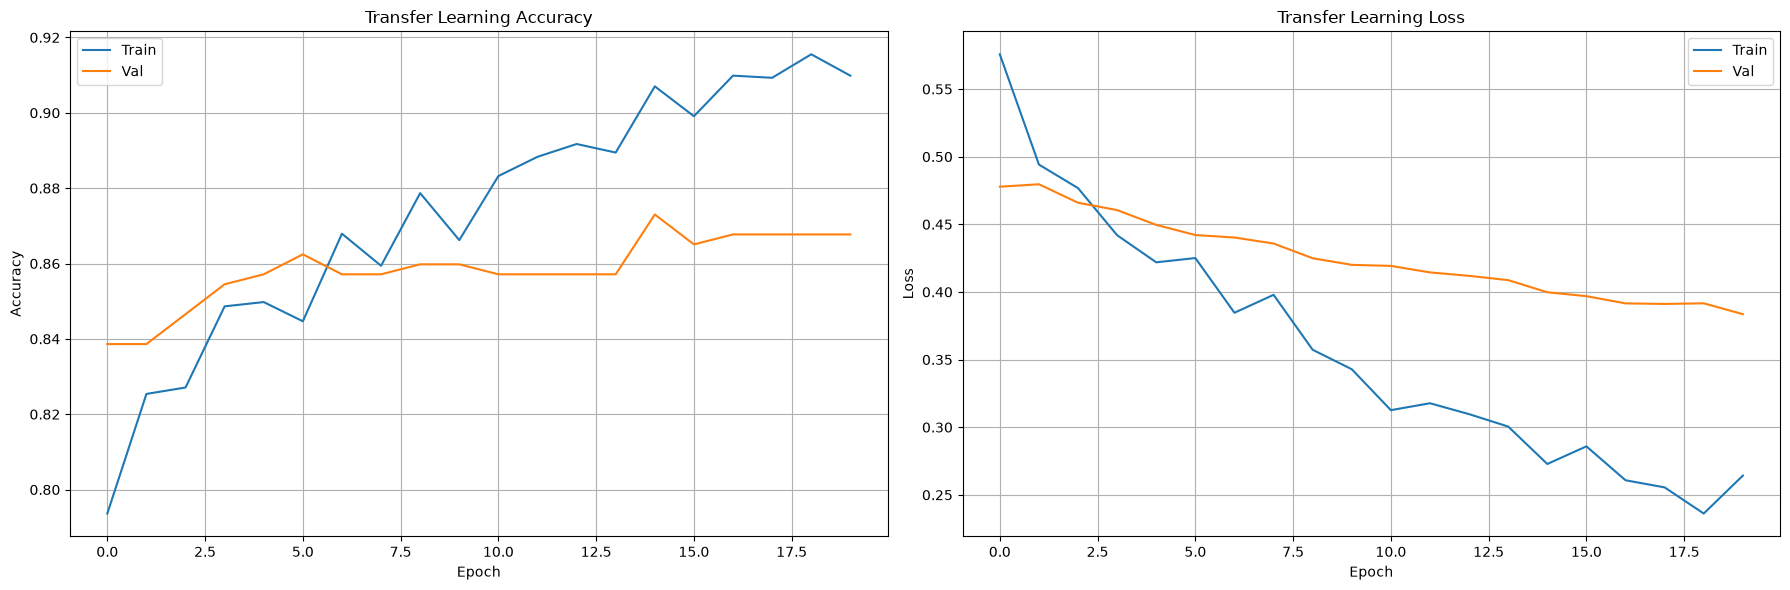

In [ ]:
plot_history(history_fine_tuning)

### Paso 6. Guardar modelo

In [12]:
# Guardado de modelo
model_name = "best_model_v3_large-20260915.keras"
# model_name = "test-taco-trashnet.keras"
target_folder = "/Users/jairpalma/Development/Reciclame/dataset_for_model"
modelSavedPath = target_folder + "/" + model_name
model.save(modelSavedPath)
print("Modelo guardado.....")

Modelo guardado.....


### Paso 7. Realizar inferencias con el modelo entrenado Keras

/Users/jairpalma/Development/Reciclame/test_images/IMG_6276.jpg
/Users/jairpalma/Development/Reciclame/test_images/IMG_6274.jpg
/Users/jairpalma/Development/Reciclame/test_images/IMG_6275.jpg
/Users/jairpalma/Development/Reciclame/test_images/IMG_6271.png
/Users/jairpalma/Development/Reciclame/test_images/IMG_6270.png
/Users/jairpalma/Development/Reciclame/test_images/IMG_6272.jpg
/Users/jairpalma/Development/Reciclame/test_images/IMG_6273.jpg
/Users/jairpalma/Development/Reciclame/test_images/IMG_6269.jpg
Total valid files: 8


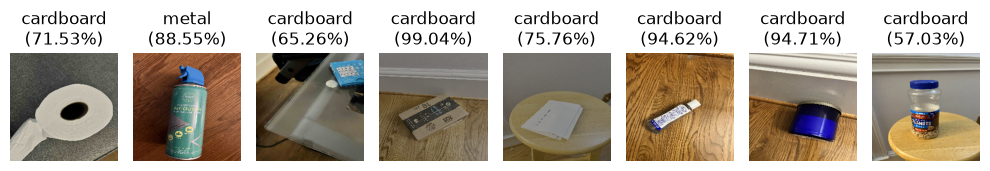

In [13]:
# Definir tus clases en el mismo orden que durante el entrenamiento
def predecir_imagen(image_path, model):
    # Cargar y redimensionar la imagen a 224x224
    img = keras.utils.load_img(image_path, target_size=(224, 224))
    img_array = keras.utils.img_to_array(img)
    
    # Expandir dimensiones para simular el batch: de [224, 224, 3] a [1, 224, 224, 3]
    img_batch = np.expand_dims(img_array, axis=0)
    
    # Preprocesamiento oficial de MobileNetV3
    img_preprocessed = keras.applications.mobilenet_v3.preprocess_input(img_batch)
    
    # Inferencia (training=False asegura que no se aplique data augmentation ni dropout)
    predictions = model(img_preprocessed, training=False).numpy()
    
    class_idx = np.argmax(predictions[0])
    confidence = np.max(predictions[0]) * 100
    predicted_label = class_names[class_idx]
    
    return img, predicted_label, confidence

# Cargar tu modelo guardado
target_folder = "/Users/jairpalma/Development/Reciclame/dataset_for_model"
model_path = os.path.join(target_folder, model_name)
model = keras.models.load_model(model_path)

# Probar con una o varias imágenes
test_images_path = "/Users/jairpalma/Development/Reciclame/test_images/"
imagenes_prueba = []
for filename in os.listdir(test_images_path):
        file_path = os.path.join(test_images_path, filename)
        print(file_path)
        # Ignorar directorios y archivos de tamaño 0
        if os.path.isfile(file_path):
            if os.path.getsize(file_path) > 0:
                imagenes_prueba.append(file_path)
            else:
                print(f"{filename} is 0 length, ignore it.....")
    
total_files = len(imagenes_prueba)
print(f"Total valid files: {total_files}")

plt.figure(figsize=(10, 5))
for i, img_path in enumerate(imagenes_prueba):
    img, label, conf = predecir_imagen(img_path, model)
    
    plt.subplot(1, len(imagenes_prueba), i + 1)
    plt.imshow(img)
    plt.title(f"{label}\n({conf:.2f}%)")
    plt.axis('off')

plt.tight_layout()
plt.show()

### 8. Exportar modelo a ONNX

In [14]:
model_onnx = os.path.join(target_folder, "best-mobilenet_large-trash-20260915.onnx")

# Load the model (works for .keras, .h5, or SavedModel directories)
model = load_model(modelSavedPath)

# Definimos la firma con la forma estática exacta NCHW: [1, 3, 224, 224]
# tf.float32 equivale a System.Single en C#
input_signature = [
    tf.TensorSpec(shape=(1, 3, 224, 224), dtype=tf.float32, name="input")
]

# 3. Función envoltorio que transpone NCHW -> NHWC internamente
@tf.function(input_signature=input_signature)
def model_nchw(x):
    # Transponer de [batch, channels, height, width] a [batch, height, width, channels]
    x_nhwc = tf.transpose(x, perm=[0, 2, 3, 1])
    # Ejecutamos la inferencia (training=False desactiva dropout/batchnorm updates)
    preds = model(x_nhwc, training=False)
    # Si la salida no tiene nombre explícito o necesitas nombrarla:
    return tf.identity(preds, name="output")

# Convertir a ONNX
# Recomendamos opset >= 13 para MobileNetV3 (por HardSwish/HardSigmoid)
onnx_model, _ = tf2onnx.convert.from_function(
    model_nchw,
    input_signature=input_signature,
    opset=17,  # 13, 16 o 17 son excelentes para ONNX Runtime moderno
    output_path=model_onnx
)

print("¡Modelo exportado con éxito!")

2026-09-15 16:45:49.991477: I tensorflow/core/grappler/devices.cc:75] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
2026-09-15 16:45:49.991912: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-09-15 16:45:49.991923: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-09-15 16:45:50.580409: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-09-15 16:45:50.580430: I tensorflow/core/com

¡Modelo exportado con éxito!


### Paso 9. Realizar inferencias con el modelo entrenado ONNX

In [15]:
# Inicializar sesión de ONNX Runtime
# model_onnx = "mobilenetlarge-trash.onnx"

session = ort.InferenceSession(os.path.join(target_folder, model_onnx))

# Cargar y preparar imagen en NCHW [1, 3, 224, 224]
img = Image.open("/Users/jairpalma/Development/Reciclame/test_images/IMG_6270.png").convert("RGB").resize((224, 224))
arr = np.array(img, dtype=np.float32)

# Si tu exportación ya tiene la transposición interna, pasa [1, 3, 224, 224]:
# Transponer de HWC [224, 224, 3] a CHW [3, 224, 224]
arr_chw = np.transpose(arr, (2, 0, 1))
input_tensor = np.expand_dims(arr_chw, axis=0) # [1, 3, 224, 224]

# Ejecutar sesión ONNX
input_name = session.get_inputs()[0].name
output_name = session.get_outputs()[0].name

preds = session.run([output_name], {input_name: input_tensor})[0]

"""
i = 0
for predictions in preds:
    for pred in predictions:
        print(f"Class: {class_names[i]} confidence: {(pred * 100):.2f}")
        i = i + 1
"""

# Interpretar resultado
class_idx = np.argmax(preds[0])
confidence = np.max(preds[0]) * 100
print(f"Predicción ONNX: {class_names[class_idx]} ({confidence:.2f}%)")
# print(class_names)

Predicción ONNX: cardboard (85.47%)
